In [3]:
# portfolio_backtest — cross-sectional long/short weekly backtest with risk controls

from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

ROOT = Path("..")
CUR  = ROOT / "data" / "curated"
MET  = ROOT / "data" / "metrics"
for p in [CUR, MET]: p.mkdir(parents=True, exist_ok=True)

# 檔案
PRED_FP = CUR / "ml_preds_weekly.parquet"  # 07 的輸出
FACT_FP = CUR / "factors_weekly.parquet"   # 含 ret_simple_weekly / rf_weekly
FMP_FP  = CUR / "fmp_weekly.parquet"       # 含 CMKT（及 CSMB/CMOM 如有）

# 主要回測/風控參數（可自行調整）
PARAMS = dict(
    Q=5,                        # 分位數（Top/Bottom 分組）
    GROSS_LEV=1.0,              # |w_long| + |w_short|
    MAX_W_PER_ASSET=0.10,       # 單名額上限
    TC_BPS=10,                  # 單邊交易成本（bps）
    MAX_TURNOVER_ASSET=0.30,    # 單名額單週最大換手
    VOL_TARGET_ANN=0.30,        # 年化波動目標
    VOL_ROLL_WEEKS=26,          # 滾動視窗（vol targeting）
    BETA_ROLL_WEEKS=52,         # 估對 CMKT 的 beta 視窗
    BETA_NEUTRAL=True,          # 是否 β-neutral
    VOL_TARGET=True             # 是否啟用 vol targeting
)

print("params:", json.dumps(PARAMS, indent=2))


params: {
  "Q": 5,
  "GROSS_LEV": 1.0,
  "MAX_W_PER_ASSET": 0.1,
  "TC_BPS": 10,
  "MAX_TURNOVER_ASSET": 0.3,
  "VOL_TARGET_ANN": 0.3,
  "VOL_ROLL_WEEKS": 26,
  "BETA_ROLL_WEEKS": 52,
  "BETA_NEUTRAL": true,
  "VOL_TARGET": true
}


In [4]:
# 預測（ml 輸出）
pred = pd.read_parquet(PRED_FP).copy()
pred["date_week"] = pd.to_datetime(pred["date_week"]).dt.tz_localize(None)

# 事後實際報酬（下一週報酬將以當期 ret 欄位代表；07 的 y_fwd1 就是下一週超額報酬，用來評估 RankIC）
fact = pd.read_parquet(FACT_FP).copy()
fact["date_week"] = pd.to_datetime(fact["date_week"]).dt.tz_localize(None)
if "rf_weekly" not in fact.columns:
    fact["rf_weekly"] = 0.0

# 資產鍵（優先使用已存在的欄位）
ASSET_KEYS = ["market", "symbol", "coingecko_id"]
asset_key = next((k for k in ASSET_KEYS if k in pred.columns), None)
if asset_key is None:
    asset_key = next((k for k in ASSET_KEYS if k in fact.columns), None)
if asset_key is None:
    asset_key = "_asset"
    pred["_asset"] = "asset_0"
    fact["_asset"] = "asset_0"

# 統一 symbol 大寫（若存在）
for df_ in [pred, fact]:
    if "symbol" in df_.columns:
        df_["symbol"] = df_["symbol"].astype(str).str.upper()

# 合併預測與實際（當期 ret 即持有 t->t+1 週的實際報酬；07 已將目標對齊為 y_fwd1）
cols_keep = ["date_week", asset_key, "ret_simple_weekly", "rf_weekly"]
m = pred.merge(fact[cols_keep], on=["date_week", asset_key], how="left") \
        .rename(columns={"ret_simple_weekly": "ret"})
m = m.sort_values([asset_key, "date_week"]).reset_index(drop=True)

print("merged rows:", len(m), "| weeks:", m["date_week"].nunique(), "| assets:", m[asset_key].nunique())
display(m.head(3))


merged rows: 4754 | weeks: 325 | assets: 31


,date_week,market,y_fwd1,y_pred_ranker,y_pred_ridge,y_pred,ret,rf_weekly
0,2019-07-07,ADA/USDT,-0.256838,0.028285,-0.000728,0.019581,-0.031121,0.0
1,2019-07-14,ADA/USDT,0.031065,-0.046311,-0.003345,-0.033421,-0.256838,0.0
2,2019-07-21,ADA/USDT,-0.028001,-0.494006,-0.003464,-0.346843,0.031065,0.0


In [5]:
# 讀因子（至少要有 CMKT）
fmp = pd.read_parquet(FMP_FP).copy()
fmp["date_week"] = pd.to_datetime(fmp["date_week"]).dt.tz_localize(None)
if "CMKT" not in fmp.columns:
    raise SystemExit("fmp_weekly.parquet 缺少 CMKT 欄位。請先用 build_fmp.py 產生因子模擬組合。")

cmkt = fmp[["date_week", "CMKT"]].dropna()

def rolling_beta_to_cmkt(df_one: pd.DataFrame, win: int) -> pd.DataFrame:
    """
    OLS：ret_i ~ a + b * CMKT，在每個資產內用過去 win 週估 β。
    回傳 columns: date_week, beta_cmkt
    """
    out = []
    g = df_one.merge(cmkt, on="date_week", how="left").dropna(subset=["ret","CMKT"]).copy()
    for i in range(win, len(g)+1):
        sub = g.iloc[i-win:i]
        x = sub["CMKT"].values
        y = sub["ret"].values
        X = np.vstack([np.ones_like(x), x]).T
        try:
            b = np.linalg.lstsq(X, y, rcond=None)[0][1]
        except Exception:
            b = np.nan
        out.append({"date_week": sub["date_week"].iloc[-1], "beta_cmkt": b})
    return pd.DataFrame(out)

# 估各資產滾動 β（僅在需要 β-neutral 時）
beta_df = []
if PARAMS["BETA_NEUTRAL"]:
    for aid, g in m.groupby(asset_key):
        rb = rolling_beta_to_cmkt(g[[asset_key, "date_week", "ret"]].copy(), win=PARAMS["BETA_ROLL_WEEKS"])
        if not rb.empty:
            rb[asset_key] = aid
            beta_df.append(rb)
    beta_df = pd.concat(beta_df, ignore_index=True) if beta_df else pd.DataFrame(columns=["date_week","beta_cmkt",asset_key])
else:
    beta_df = pd.DataFrame(columns=["date_week","beta_cmkt",asset_key])

print("beta rows:", len(beta_df))
display(beta_df.head(3))


beta rows: 3300


,date_week,beta_cmkt,market
0,2020-06-28,0.196860,ADA/USDT
1,2020-07-05,0.258111,ADA/USDT
2,2020-07-12,0.276750,ADA/USDT


In [6]:
def beta_neutralize(w: pd.Series, beta: pd.Series) -> pd.Series:
    """
    調整權重 w 使 Σ w_i β_i = 0；若 β 不足或分母太小，回傳原 w。
    """
    beta = beta.reindex(w.index).fillna(0.0)
    num = float((w * beta).sum())
    den = float((beta ** 2).sum())
    if den <= 1e-12:
        return w
    lam = num / den
    return w - lam * beta

def apply_turnover_cap(w_prev: pd.Series, w_target: pd.Series, cap: float) -> pd.Series:
    """
    對單一名額的權重變化 |Δw_i| 套上上限 cap，回傳新權重。
    """
    w_prev = w_prev.reindex(w_target.index).fillna(0.0)
    delta = (w_target - w_prev).clip(-cap, cap)
    return w_prev + delta, delta

def sharpe_annual(weekly_ret: pd.Series) -> float:
    mu = weekly_ret.mean() * 52
    sd = weekly_ret.std() * np.sqrt(52)
    return float(mu / sd) if sd > 1e-12 else np.nan

def max_drawdown(cum: pd.Series) -> float:
    peak = cum.cummax()
    dd = (cum/peak - 1.0)
    return float(dd.min())

def summarize_bt(df: pd.DataFrame, col: str = "ret_net_vt") -> pd.Series:
    s = {}
    s["weeks"]        = int(len(df))
    s["ann_return"]   = df[col].mean() * 52
    s["ann_vol"]      = df[col].std() * np.sqrt(52)
    s["sharpe"]       = sharpe_annual(df[col])
    s["mdd"]          = max_drawdown((1 + df[col]).cumprod())
    s["avg_turnover"] = df["turnover"].mean()
    s["avg_tc_bps"]   = df["tc"].mean() * 1e4
    s["beta_cmkt"]    = df["beta_cmkt_port"].mean() if "beta_cmkt_port" in df.columns else np.nan
    return pd.Series(s)


In [9]:
def backtest_from_pred(
    pred_df: pd.DataFrame,
    params: dict,
    asset_key: str,
    beta_df: pd.DataFrame = None,
    cmkt_df: pd.DataFrame = None
) -> pd.DataFrame:
    """
    以預測分數 y_pred 建立長短多空組合，回傳逐週績效表。
    pred_df 需要欄位：date_week, asset_key, y_pred, ret（當週實際報酬）
    """
    Q = params["Q"]; GROSS = params["GROSS_LEV"]; MAX_W = params["MAX_W_PER_ASSET"]
    TC_BPS = params["TC_BPS"]; MAX_TO = params["MAX_TURNOVER_ASSET"]
    VOL_TGT = params["VOL_TARGET_ANN"]; VOL_WIN = params["VOL_ROLL_WEEKS"]
    DO_BETA = params["BETA_NEUTRAL"]; DO_VT = params["VOL_TARGET"]

    all_dates = sorted(pred_df["date_week"].unique())
    w_prev = pd.Series(dtype=float)
    rows = []

    for d in all_dates:
        g = pred_df[pred_df["date_week"] == d].dropna(subset=["y_pred","ret"]).copy()
        if len(g) < 10:
            continue

        # 依 y_pred 分位數切 Top / Bottom
        try:
            q = pd.qcut(g["y_pred"], Q, labels=False, duplicates="drop")
        except Exception:
            # 若 qcut 失敗（樣本少或重複多），改用 rank 百分位
            rk = g["y_pred"].rank(method="average", pct=True)
            q = np.floor(rk * Q).clip(0, Q-1).astype(int)

        g = g.assign(bucket=q)
        long  = g[g["bucket"] == g["bucket"].max()]
        short = g[g["bucket"] == g["bucket"].min()]
        if len(long) == 0 or len(short) == 0:
            continue

        # 初始等權（長為 +，短為 −），並做單名額上限
        w_long  = pd.Series(GROSS/2 / len(long), index=long[asset_key])
        w_short = pd.Series(-GROSS/2 / len(short), index=short[asset_key])
        w = pd.concat([w_long, w_short]).groupby(level=0).sum()
        w = w.clip(-MAX_W, MAX_W)

        # β-neutral（若啟用）
        if DO_BETA and beta_df is not None and not beta_df.empty:
            beta_now = beta_df[beta_df["date_week"] == d].set_index(asset_key)["beta_cmkt"]
            w = beta_neutralize(w, beta_now)

        # 正規化總槓桿回到 GROSS
        gross = w.abs().sum()
        if gross > 1e-12:
            w = w * (GROSS / gross)

        # turnover cap
        w, delta = apply_turnover_cap(w_prev.reindex(w.index).fillna(0.0), w, MAX_TO)

        # 再正規化（避免 cap 後槓桿漂移）
        gross = w.abs().sum()
        if gross > 1e-12:
            w = w * (GROSS / gross)

        # 交易成本（對當期調整量 delta 收費）
        tc = float(delta.abs().sum()) * (TC_BPS / 1e4)

        # 本週持有報酬
        r = g.set_index(asset_key)["ret"].reindex(w.index).fillna(0.0)
        ret_gross = float((w * r).sum())
        ret_net   = ret_gross - tc

        # 組合 β（監控用）
        beta_now = None
        if DO_BETA and beta_df is not None and not beta_df.empty:
            beta_now = beta_df[beta_df["date_week"] == d].set_index(asset_key)["beta_cmkt"].reindex(w.index)
            beta_port = float((w * beta_now.fillna(0.0)).sum())
        else:
            beta_port = np.nan

        rows.append({
            "date_week": d,
            "ret_gross": ret_gross,
            "ret_net": ret_net,
            "turnover": float(delta.abs().sum()),
            "tc": tc,
            "n_long": int((w>0).sum()),
            "n_short": int((w<0).sum()),
            "beta_cmkt_port": beta_port
        })

        w_prev = w.copy()

    port = pd.DataFrame(rows).sort_values("date_week").reset_index(drop=True)

    # Vol targeting（若啟用）
    if DO_VT and not port.empty:
        target_sigma_w = VOL_TGT / np.sqrt(52)
        port["vol_scale"] = 1.0
        for i in range(VOL_WIN, len(port)):
            sigma = port["ret_net"].iloc[i-VOL_WIN:i].std()
            if pd.notna(sigma) and sigma > 1e-8:
                scale = target_sigma_w / sigma
                scale = float(np.clip(scale, 0.5, 2.0))  # 安全夾
            else:
                scale = 1.0
            port.loc[i, "vol_scale"] = scale
        port["ret_net_vt"] = port["ret_net"] * port["vol_scale"]
    else:
        port["vol_scale"] = 1.0
        port["ret_net_vt"] = port["ret_net"]

    return port


,value
weeks,325.000000
ann_return,5239.582120
ann_vol,13099.002622
sharpe,0.399999
mdd,-0.829822
avg_turnover,0.802144
avg_tc_bps,8.021445
beta_cmkt,-0.000182


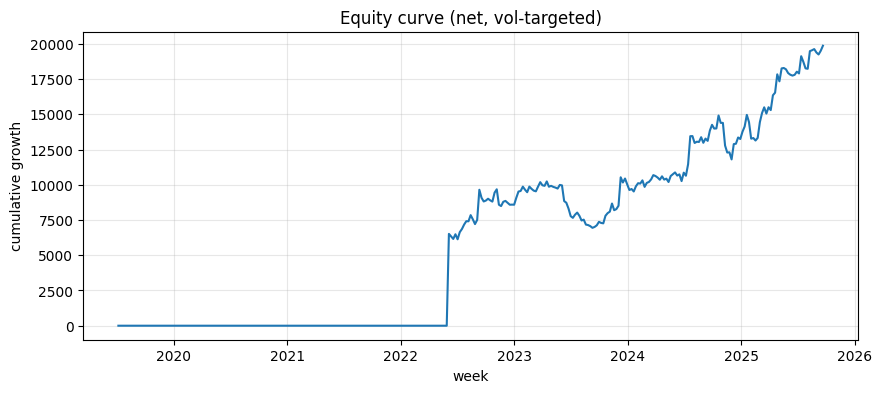

saved backtest: ../data/curated/backtest_ml_longshort.parquet
saved summary : ../data/metrics/backtest_summary_20251001.json


,date_week,ret_gross,ret_net,turnover,tc,n_long,n_short,beta_cmkt_port,vol_scale,ret_net_vt
0,2019-07-07,0.051507,0.050507,1.000000,0.001000,3,3,0.0,1.0,0.050507
1,2019-07-14,0.012600,0.012100,0.500000,0.000500,3,3,0.0,1.0,0.012100
2,2019-07-21,0.019001,0.018334,0.666667,0.000667,3,3,0.0,1.0,0.018334
3,2019-07-28,-0.040123,-0.040790,0.666667,0.000667,3,3,0.0,1.0,-0.040790
4,2019-08-04,0.006708,0.005908,0.800000,0.000800,3,3,0.0,1.0,0.005908


In [10]:
# 基準回測（使用 PARAMS）
port = backtest_from_pred(
    pred_df=m.rename(columns={"y_pred":"y_pred"}),  # 直接用 m 的 y_pred
    params=PARAMS,
    asset_key=asset_key,
    beta_df=beta_df,
    cmkt_df=cmkt
)

if port.empty:
    raise SystemExit("回測組合為空，請檢查預測檔或參數（樣本數是否太少？）")

# 摘要績效
sum_tbl = summarize_bt(port, col="ret_net_vt").to_frame("value")
display(sum_tbl)

# 權益曲線
eq = (1 + port["ret_net_vt"]).cumprod()
plt.figure(figsize=(10,4))
plt.plot(port["date_week"], eq)
plt.title("Equity curve (net, vol-targeted)")
plt.xlabel("week")
plt.ylabel("cumulative growth")
plt.grid(True, alpha=0.3)
plt.show()

# 儲存回測明細與摘要
OUT_BT = CUR / "backtest_ml_longshort.parquet"
port.to_parquet(OUT_BT, index=False)
OUT_SUM = MET / f"backtest_summary_{pd.Timestamp.utcnow().strftime('%Y%m%d')}.json"
with open(OUT_SUM, "w") as f:
    json.dump({k: float(v) if isinstance(v, (np.floating,)) else v for k,v in summarize_bt(port).to_dict().items()}, f, indent=2)

print("saved backtest:", OUT_BT)
print("saved summary :", OUT_SUM)

# 顯示前幾列
display(port.head(5))


In [11]:
def run_sensitivity(pred_table: pd.DataFrame, base_params: dict, Q_list=(3,5,7), TC_list=(5,10,20)):
    rows = []
    for Q in Q_list:
        for tc in TC_list:
            p = dict(base_params)
            p["Q"] = Q
            p["TC_BPS"] = tc
            bt = backtest_from_pred(pred_table, p, asset_key, beta_df, cmkt)
            s = summarize_bt(bt).to_dict()
            s.update({"Q": Q, "TC_BPS": tc})
            rows.append(s)
    return pd.DataFrame(rows).sort_values(["Q","TC_BPS"])

sens = run_sensitivity(m, PARAMS, Q_list=(3,5,7), TC_list=(5,10,20))
display(sens[["Q","TC_BPS","sharpe","ann_return","ann_vol","mdd","avg_turnover","avg_tc_bps"]])


,Q,TC_BPS,sharpe,ann_return,ann_vol,mdd,avg_turnover,avg_tc_bps
0,3,5,0.400018,2788.175823,6970.125816,-0.599757,0.813908,4.069538
1,3,10,0.400015,2789.758706,6974.142332,-0.627995,0.813908,8.139077
2,3,20,0.400008,2792.717657,6981.658260,-0.679622,0.813908,16.278153
3,5,5,0.400000,5236.964201,13092.412728,-0.819372,0.802144,4.010722
4,5,10,0.399999,5239.582120,13099.002622,-0.829822,0.802144,8.021445
5,5,20,0.399996,5244.668371,13111.808357,-0.848926,0.802144,16.042889
6,7,5,0.400016,3316.362230,8290.565416,-0.554514,0.779450,3.897250
7,7,10,0.400015,3315.856680,8289.339237,-0.563092,0.779450,7.794500
8,7,20,0.400011,3314.820010,8286.822906,-0.579748,0.779450,15.589000
